In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import layers, models

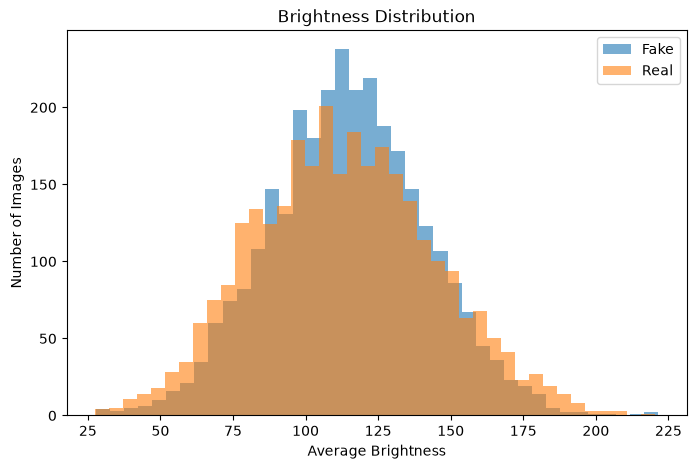

In [2]:


data_dir = "dataset"

# 클래스 폴더
class_names = ["Fake", "Real"]

brightness_data = {}

for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    # 너무 많으므로 최대 3000장만 랜덤 추출
    sample_size = min(3000, len(files))
    sample_files = np.random.choice(files, sample_size, replace=False)

    brightness_values = []

    for file in sample_files:
        img_path = os.path.join(class_path, file)

        img = Image.open(img_path).convert("L")   # 흑백 변환
        img_array = np.array(img)

        # 이미지 한 장의 평균 밝기
        brightness_values.append(img_array.mean())

    brightness_data[class_name] = brightness_values


# 시각화
plt.figure(figsize=(8, 5))

plt.hist(
    brightness_data["Fake"],
    bins=40,
    alpha=0.6,
    label="Fake"
)

plt.hist(
    brightness_data["Real"],
    bins=40,
    alpha=0.6,
    label="Real"
)

plt.title("Brightness Distribution")
plt.xlabel("Average Brightness")
plt.ylabel("Number of Images")
plt.legend()

plt.show()

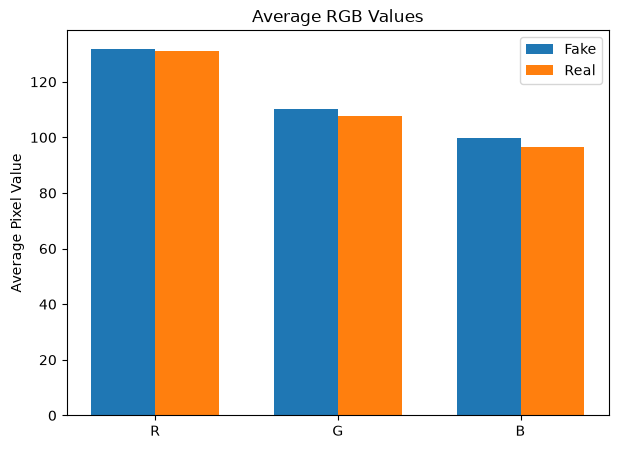

In [3]:

data_dir = "dataset"
class_names = ["Fake", "Real"]

rgb_means = {}

for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    sample_size = min(3000, len(files))
    sample_files = np.random.choice(files, sample_size, replace=False)

    r_values = []
    g_values = []
    b_values = []

    for file in sample_files:
        img_path = os.path.join(class_path, file)

        img = Image.open(img_path).convert("RGB")
        img_array = np.array(img)

        r_values.append(img_array[:, :, 0].mean())
        g_values.append(img_array[:, :, 1].mean())
        b_values.append(img_array[:, :, 2].mean())

    rgb_means[class_name] = [
        np.mean(r_values),
        np.mean(g_values),
        np.mean(b_values)
    ]

# 그래프
labels = ["R", "G", "B"]
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7, 5))

plt.bar(
    x - width/2,
    rgb_means["Fake"],
    width,
    label="Fake"
)

plt.bar(
    x + width/2,
    rgb_means["Real"],
    width,
    label="Real"
)

plt.xticks(x, labels)
plt.ylabel("Average Pixel Value")
plt.title("Average RGB Values")
plt.legend()

plt.show()

In [4]:
# 학습용 데이터와 예측용 데이터 분리 

train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32,
    label_mode="binary"
)

Found 161972 files belonging to 2 classes.
Using 129578 files for training.
Found 161972 files belonging to 2 classes.
Using 32394 files for validation.


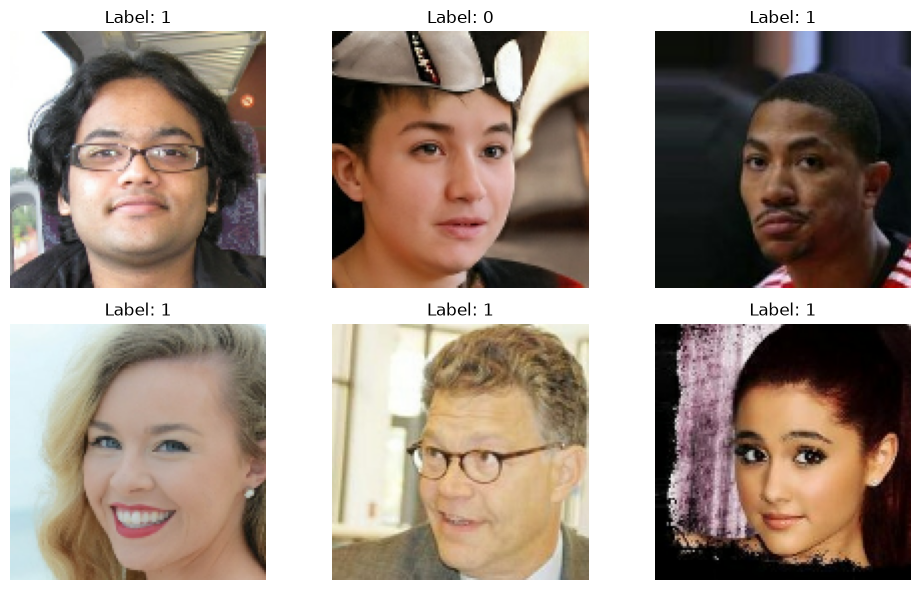

In [5]:
# 7. Sample Image 확인
plt.figure(figsize=(10, 6))

for images, labels in train_ds.take(1):
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Label: {int(labels[i].numpy()[0])}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
print(train_ds.class_names)

print("Fake:", len(os.listdir("dataset/Fake")))
print("Real:", len(os.listdir("dataset/Real")))

['Fake', 'Real']
Fake: 80972
Real: 81000


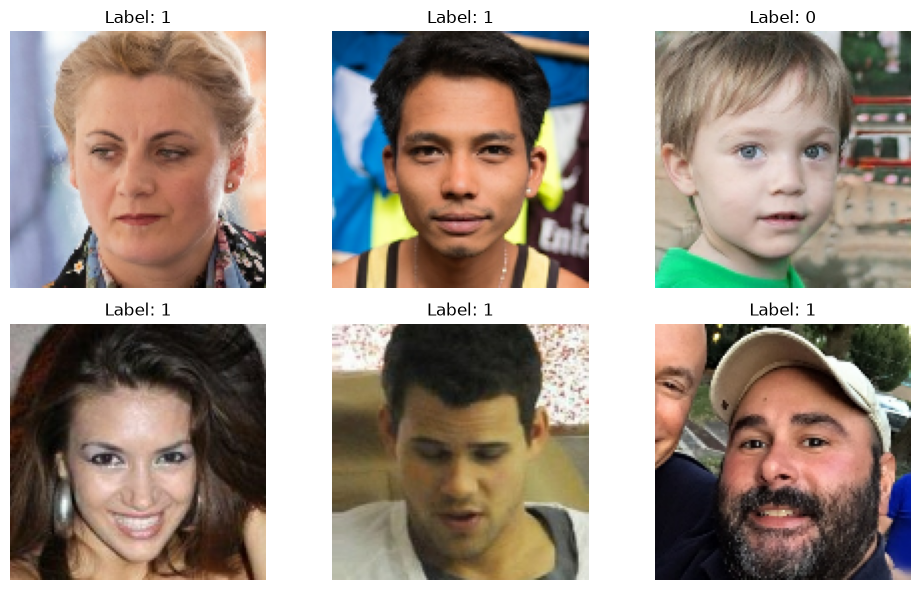

In [7]:
# 7. Sample Image 확인
plt.figure(figsize=(10, 6))

for images, labels in train_ds.take(1):
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Label: {int(labels[i].numpy()[0])}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# 0~1 정규화
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))   
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [9]:
model = models.Sequential([
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [10]:
#구조 확인
model.build((None, 128, 128, 3))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
# EarlyStopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# ModelCheckpoint
model_checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [13]:
history = model.fit(train_ds,validation_data=val_ds,epochs=15,callbacks=[early_stop])

Epoch 1/15


c:\Users\capto\Desktop\project\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


 248/4050 ━━━━━━━━━━━━━━━━━━━━ 7:29 118ms/step - accuracy: 0.5089 - loss: 0.6931

KeyboardInterrupt: 

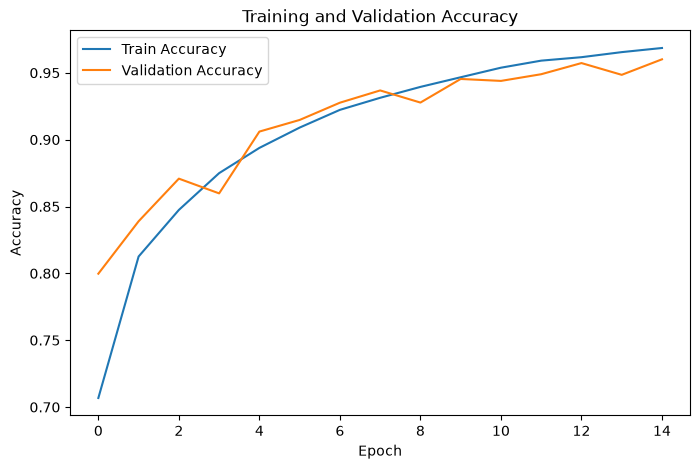

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

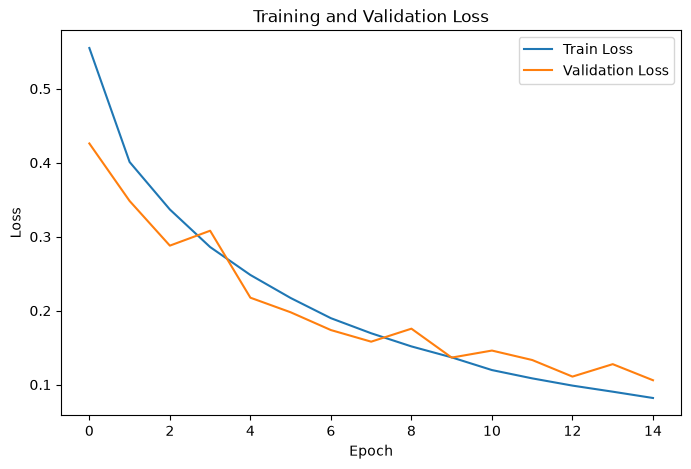

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

1013/1013 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - accuracy: 0.9601 - loss: 0.1059
Validation Loss: 0.10591095685958862
Validation Accuracy: 0.9600852131843567


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_true = []
y_pred = []
y_score = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    # 실제 정답
    y_true.extend(labels.numpy().flatten().astype(int))

    # ROC용 확률값
    y_score.extend(predictions.flatten())

    # Confusion Matrix용 예측값
    pred_labels = (predictions.flatten() >= 0.5).astype(int)
    y_pred.extend(pred_labels)

y_true = np.array(y_true)
y_score = np.array(y_score)
y_pred = np.array(y_pred)

print("평가 이미지 수:", len(y_true))

평가 이미지 수: 32394


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    pred_labels = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy().astype(int).flatten())
    y_pred.extend(pred_labels.flatten())

cm = confusion_matrix(y_true, y_pred)

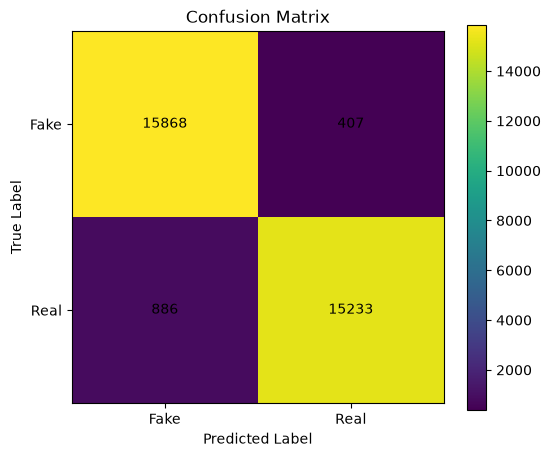

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Fake", "Real"])
plt.yticks([0, 1], ["Fake", "Real"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Fake", "Real"]
    )
)

              precision    recall  f1-score   support

        Fake       0.95      0.97      0.96     16275
        Real       0.97      0.95      0.96     16119

    accuracy                           0.96     32394
   macro avg       0.96      0.96      0.96     32394
weighted avg       0.96      0.96      0.96     32394



In [ ]:
print("모델 출력 형태:", model.output_shape)

모델 출력 형태: (None, 1)


데이터 개수: 32394
예측 확률 범위: 1.4549183e-16 ~ 1.0
직접 계산 Accuracy: 0.9600852009631413
AUC: 0.9941051276751283

Confusion Matrix
[[15868   407]
 [  886 15233]]

Classification Report
              precision    recall  f1-score   support

        Fake       0.95      0.97      0.96     16275
        Real       0.97      0.95      0.96     16119

    accuracy                           0.96     32394
   macro avg       0.96      0.96      0.96     32394
weighted avg       0.96      0.96      0.96     32394



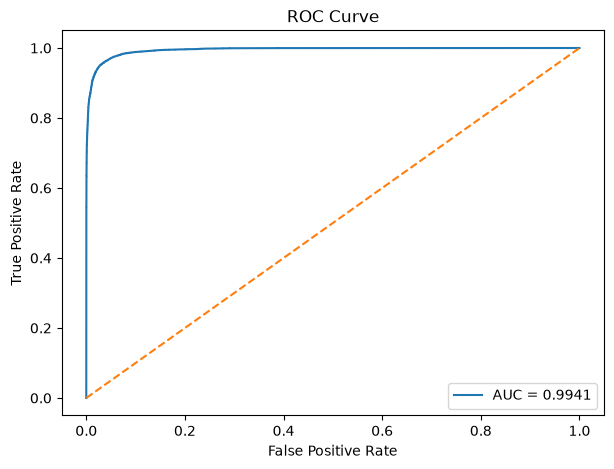

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

y_true = []
y_score = []

for images, labels in val_ds:
    pred = model(images, training=False).numpy().reshape(-1)

    y_true.extend(labels.numpy().reshape(-1))
    y_score.extend(pred)

y_true = np.array(y_true).astype(int)
y_score = np.array(y_score)

# 0.5 기준 최종 예측
y_pred = (y_score >= 0.5).astype(int)

print("데이터 개수:", len(y_true))
print("예측 확률 범위:", y_score.min(), "~", y_score.max())
print("직접 계산 Accuracy:", accuracy_score(y_true, y_pred))
print("AUC:", roc_auc_score(y_true, y_score))

print("\nConfusion Matrix")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Fake", "Real"]
    )
)

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_score)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_true, y_score):.4f}"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

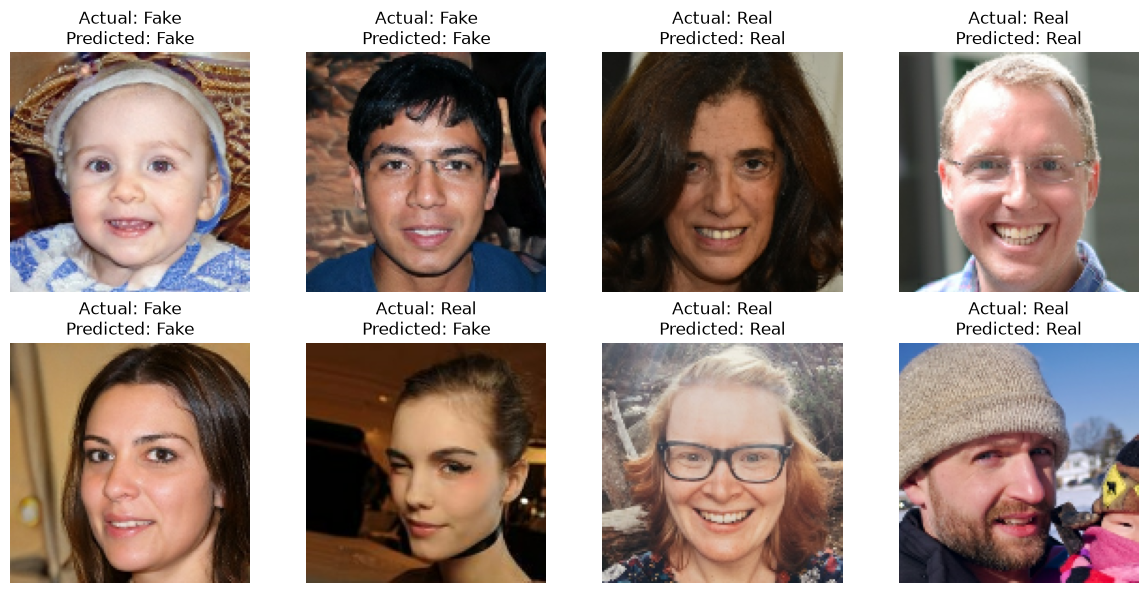

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

for images, labels in val_ds.take(1):
    predictions = model(images, training=False).numpy().reshape(-1)
    pred_labels = (predictions >= 0.5).astype(int)

    for i in range(8):
        plt.subplot(2, 4, i + 1)

        img = images[i].numpy()
        plt.imshow(np.clip(img, 0, 1))

        true_name = "Real" if labels[i].numpy().item() == 1 else "Fake"
        pred_name = "Real" if pred_labels[i] == 1 else "Fake"

        plt.title(f"Actual: {true_name}\nPredicted: {pred_name}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("best_model.keras")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 297, 297, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 146, 146, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 35, 35, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 156800)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    20,070,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,491,717 (230.76 MB)

 Trainable params: 20,163,905 (76.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 40,327,812 (153.84 MB)